# Two steps neural network 
Time and diffusive parameters

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
from itertools import product
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

In [2]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [3]:
Discretizations= np.loadtxt(
    "../DATA_reaction/Discretizations.txt"
).astype(
    int
)[::-1]

####################
Discr=np.array([46])

In [4]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test, t_HF_test) = import_data(file_path_HF)
t_HF_test=t_HF_test.T
U_HF_test = U_HF_test[:, :, 44,44]

In [5]:
########################     NORMALIZATION  #########################
# Input

reaction_HF_test = normalization(reaction_HF_test)
t_HF_test=normalization(t_HF_test)
U_HF_test=normalization(U_HF_test)


In [6]:
#########################     TRAIN SET      ##########################
Nepo = [1000, 1000]  # number of epochs for second NN: NN_HF

Nlf=200
n_HF=100

batch_size=[Nlf,n_HF]


In [7]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(t_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
t_HF = t_HF_test[permutation2][0:n_HF]

grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), t_HF_test.flatten())))

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3.5*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(3.5*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]

##
p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]  # 
##

In [8]:
U_LF_list = []
U_HF_list = []

diffusion=[5]

r2_HF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores LF MSE

********************  # Nb. nodes = 801  ********************
********************  # Diff: = 5  ********************


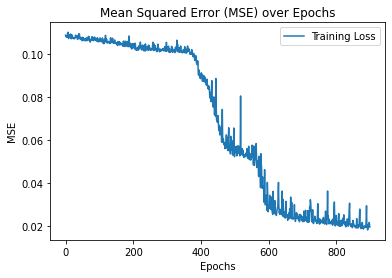

1252/1252 [==============================] - 2s 2ms/step

LF Model:
Test MSE: 0.003204404003166693
R^2: 0.9712926408752787
157/157 [==============================] - 0s 2ms/step


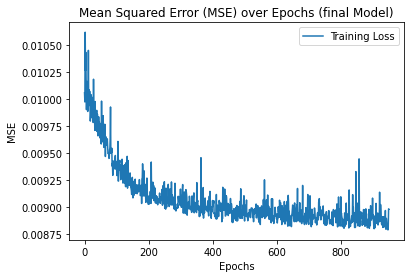

1252/1252 [==============================] - 2s 2ms/step
Elapsed time:  135.15841279999586

HF Model:
Test MSE: 0.008546733614631034
R^2: 0.9241257539174168
26/26 [==============================] - 0s 2ms/step


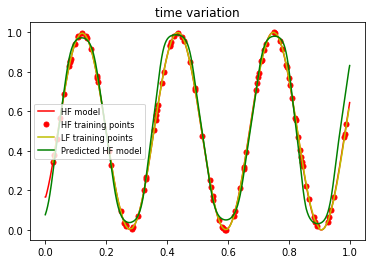

2/2 [==============================] - 0s 0s/step


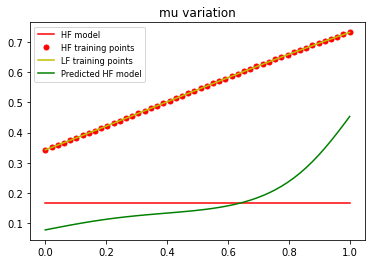

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:229: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:231: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 81  ********************
********************  # Diff: = 5  ********************


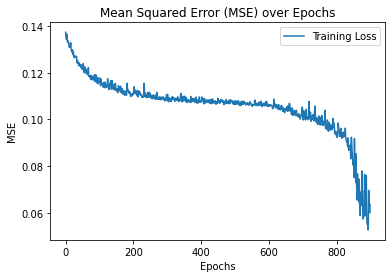

127/127 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.046552883609647565
R^2: 0.5842383662025521
157/157 [==============================] - 0s 2ms/step


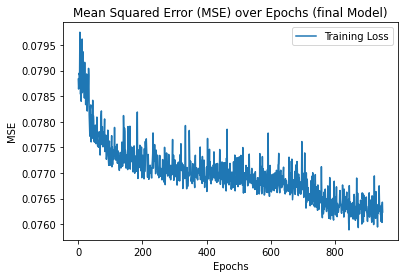

1252/1252 [==============================] - 2s 2ms/step
Elapsed time:  136.96866439998848

HF Model:
Test MSE: 0.07248869615495358
R^2: 0.35647635479697937
26/26 [==============================] - 0s 2ms/step


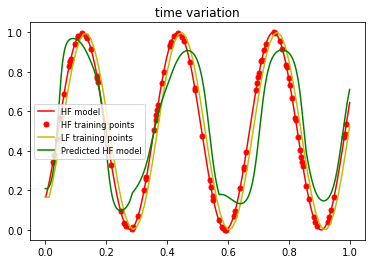

2/2 [==============================] - 0s 3ms/step


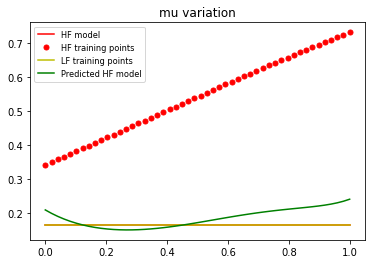

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:229: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:231: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 41  ********************
********************  # Diff: = 5  ********************


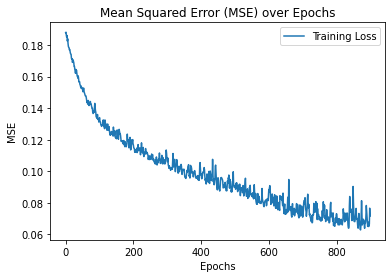

65/65 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.039855853092522285
R^2: 0.645024930603032
157/157 [==============================] - 0s 2ms/step


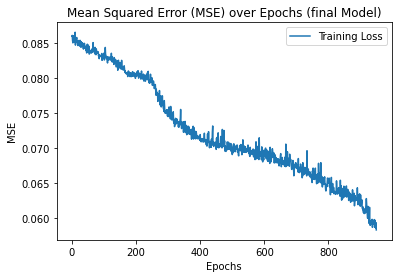

1252/1252 [==============================] - 3s 2ms/step
Elapsed time:  140.8348854999931

HF Model:
Test MSE: 0.05708344987674214
R^2: 0.4932375433140588
26/26 [==============================] - 0s 2ms/step


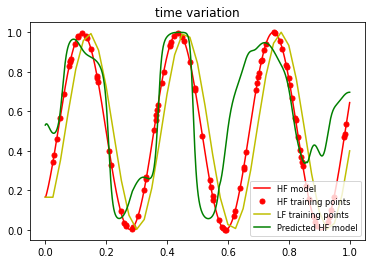

2/2 [==============================] - 0s 4ms/step


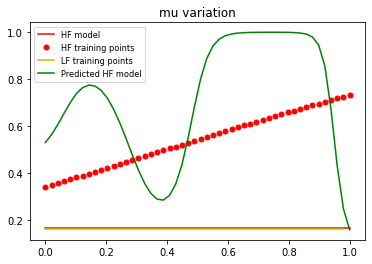

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:229: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:231: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 9  ********************
********************  # Diff: = 5  ********************


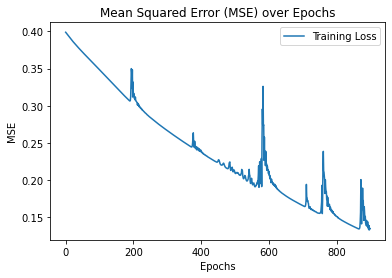

15/15 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.03684757764449261
R^2: 0.652731666445227
157/157 [==============================] - 0s 2ms/step


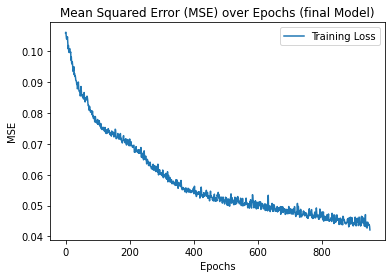

1252/1252 [==============================] - 2s 2ms/step
Elapsed time:  137.61750900000334

HF Model:
Test MSE: 0.035618087756037475
R^2: 0.6837978487165826
26/26 [==============================] - 0s 2ms/step


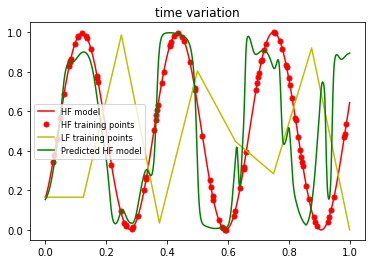

2/2 [==============================] - 0s 4ms/step


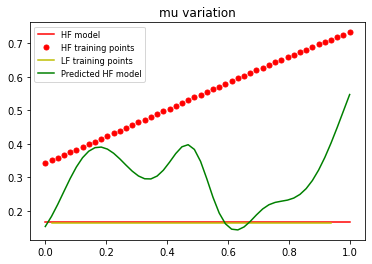

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:229: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_16552\3627381309.py:231: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

   Discretization       R2
0             0.0  0.92413
1             5.0  0.35648
2            10.0  0.49324
3            50.0  0.68380
   Discretization      MSE
0             0.0  0.00855
1             5.0  0.07249
2            10.0  0.05708
3            50.0  0.03562


In [9]:


# Name of the folder
folder_name = "2_step_models_multiparam"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               

#############à
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []

    for d in range(len(diffusion)):
        for r in range(len(Discr)):
            file_name= "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
            #file_name="Diffusion\DATA\reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
            (reaction_LF_test, U_LF_test, t_LF_test) = import_data(file_name)
            t_LF_test=t_LF_test.T
            
            U_LF_test = U_LF_test[
            :,
            :,
            int(4*(Discr[r]-1)/9),
            int(4*(Discr[r]-1)/9)
            ]
            
            
            #U_LF_test = U_LF_test[
            #:,
            #:,
            #int(4*(Discretizations[m]-1)/9),
            #int(4*(Discretizations[m]-1)/9)
            #]
            
            reaction_LF_test = normalization(reaction_LF_test)
            t_LF_test = normalization(t_LF_test)
            U_LF_test = normalization(U_LF_test)        
        
            print(
            f"********************  # Nb. nodes = {t_LF_test.shape[0]}  ********************"
            )
            
            ######### DATASET
            L=np.minimum(Nlf,t_LF_test.shape[0])
            permutation1 = np.random.permutation(len(reaction_LF_test))
            permutation2 = np.random.permutation(len(t_LF_test))
            reaction_LF = reaction_LF_test[permutation1][0:L]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
            t_LF = t_LF_test[permutation2][0:L]
            
            grid1, grid2 = np.meshgrid(reaction_LF, t_LF)
            reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))   # <--------
            reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), t_LF_test.flatten())))
            
            #
            reaction_LF=np.c_[reaction_LF, np.abs(np.sin(3.5*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
            reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(3.5*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]
            #
            
            p1, p2 = np.meshgrid(permutation1[0:L], permutation2[0:L])
            permutation = np.column_stack((p1.ravel(), p2.ravel()))
            U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
            row, col = U_LF_test.shape
            index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
            comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
            U_LF_test = U_LF_test.flatten()[comb]
            #######      

            
            print(
            f"********************  # Diff: = {diffusion[d]}  ********************"
            )
            
            ##########################       FIRST NN: NN_LF     ##########################
            K.clear_session()
            bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                }
            
            
            best_params = {
                "kernel_init": "uniform",
                "l2weight": 0.0002588943618918075,
                "lr": 0.005,
                "nodes": 64.0,
                "opt": "Adam",
            }
            
            names=["LF","HF"]
            params=[bestLF_params, best_params]
            data_train=[reaction_LF, reaction_HF]
            output_train=[U_train_LF,U_HF]
            
            model= NetworkFactory.build_network("2step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=False)

    # low fidelity part of the network 
            ULF = model.model_list[0].prediction(reaction_LF_test)
            print("low fidelity NN")

            (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test,U_LF_test)
            test_mse_LF_list.append(test_mse_LF)
            r2_LF_list.append(r2_LF)


            reaction_test_help =  model.model_list[0].prediction(reaction_HF_test)[:, 0]
            reaction_test_in = np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
            )   # <- TEST INPUT for the second NN: NN_HF

            reaction_test_help_original = model.model_list[0].prediction(reaction_HF_test)[:, 0]
            reaction_test_in_original = np.concatenate(
            (reaction_HF_test, reaction_test_help_original.reshape(-1,1)),axis=1
            )   # <- TEST INPUT for the second NN: NN_HF



            reaction_train_help = model.model_list[0].prediction(reaction_HF)[
                :, 0
            ]  # f_LF(mu_hf_train)
            reaction_final = np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
            )  # <- TRAINING INPUT for the second NN: NN_HF

            UHF =  model.model_list[1].prediction(reaction_test_in_original)
            U_HF_list.append(UHF)

            (test_mse_HF,r2_HF) = model.model_list[0].performance(reaction_test_in_original,U_HF_test)
            test_mse_HF_list.append(test_mse_HF)
            r2_HF_list.append(r2_HF)
            

            plt.figure()
            plt.plot(
            reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
            )
            plt.plot(
            reaction_LF[:, 0],
            U_train_LF,
            "yo",
            markersize=5,
            label="LF training points",
            )
            plt.plot(
            reaction_LF_test[:, 0],
            model.model_list[0].prediction(reaction_LF_test),
            "g-",
            linewidth=3,
            label="Predicted LF model",
            )
            plt.legend(prop={"size": 8.3})
            plt.show()
            
            plt.figure()
            plt.plot(
            reaction_LF_test[:, 1], U_LF_test, "y-", linewidth=1.5, label="LF model"
            )
            plt.plot(
            reaction_LF[:, 1],
            U_train_LF,
            "yo",
            markersize=5,
            label="LF training points",
            )
            plt.plot(
            reaction_LF_test[:, 1],
            model.model_list[0].prediction(reaction_LF_test),
            "g-",
            linewidth=3,
            label="Predicted LF model",
            )
            plt.legend(prop={"size": 8.3})
            plt.show()
            



            ### plot
            
            index_order=np.argsort(reaction_test_in[:,0])
            index_order_LF=np.argsort(reaction_LF[:,0])   

            plt.figure()
            mask1_test=np.where(reaction_test_in[:,0]==reaction_test_in[:,0][index_order[2]])
            mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
            mask1_LF=np.where(reaction_LF[:,0]==reaction_LF[:,0][index_order_LF[2]])
            order=np.argsort(reaction_LF[mask1_LF,1])
    # plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
    # plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
            plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
            plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
            plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
            plt.plot(
            reaction_test_in[mask1_test, 1].T,
            model.prediction(reaction_test_in[mask1_test, :][0,:,:]),
            "g-",
            markersize=5,
            label="Predicted HF model",
            )

            plt.legend(prop={"size": 8.3})  
            plt.title("time variation")
            plt.show()

            index_order=np.argsort(reaction_test_in[:,1])
            index_order_LF=np.argsort(reaction_LF[:,1])  

            plt.figure()
            mask2_test=np.where(reaction_test_in[:,1]==reaction_test_in[:,1][index_order[2]])
            mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))   
            mask2_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
            order=np.argsort(reaction_LF[mask2_LF,0])
    # plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
    # plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
            plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
            plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
            plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]][:,0], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
            plt.plot(
            reaction_test_in[mask2_test, 0].T,
            model.prediction(reaction_test_in[mask2_test, :][0,:,:]),
            "g-",
            markersize=5,
            label="Predicted HF model",
            )
            #print(U_HF_test.shape)
            #print(U_HF_test[mask2_test].shape)
            #print(U_HF[mask2])
            plt.legend(prop={"size": 8.3})
            plt.title("mu variation")
            plt.show()

            new = {'Discretization': Discretizations[m], 'R2': r2_LF_list[-1]}
            r2_LF_df=r2_LF_df.append(new, ignore_index=True)
            new = {'Discretization': Discretizations[m], 'R2': r2_HF_list[-1]}
            r2_HF_df=r2_HF_df.append(new, ignore_index=True)
            new = {'Discretization': Discretizations[m], 'MSE': test_mse_LF_list[-1]}
            mse_LF_df=mse_LF_df.append(new, ignore_index=True)
            new = {'Discretization': Discretizations[m], 'MSE': test_mse_HF_list[-1]}
            mse_HF_df=mse_HF_df.append(new, ignore_index=True)
            
            if not r2_HF_list[:-1]:
                model.save(str(Discretizations[m]),folder_path)
            elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                model.save(str(Discretizations[m]),folder_path)
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))


## Save the output

In [10]:
os.makedirs(folder_name)

r2_HF_df.to_csv(
    "./MF_LF_200_1000_HF_100_1000_2NNt_multiparam/r2_HF_MF_LF_200_1000_HF_100_1000_2NNt_multiparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./{folder_name}/mse_HF_MF_LF_200_1000_HF_100_1000_2NNt_multiparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./{folder_name}/r2_LF_MF_LF_200_1000_HF_100_1000_2NNt_multiparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./{folder_name}/mse_LF_MF_LF_200_1000_HF_100_1000_2NNt_multiparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./{folder_name}/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./{folder_name}/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)